In [5]:
from google.colab import files
uploaded = files.upload()

Saving IMDb_Movies_India[1].csv to IMDb_Movies_India[1] (1).csv


In [6]:
import pandas as pd

df = pd.read_csv("IMDb_Movies_India[1].csv", encoding="latin1")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(15509, 10)

Columns:
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

First 5 Rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita R

In [7]:
df = df[['Genre','Rating','Votes']]

df = df.dropna()

df['Votes'] = df['Votes'].astype(str)
df['Votes'] = df['Votes'].str.replace(',', '')

df = df[df['Votes'].str.isnumeric()]

df['Votes'] = df['Votes'].astype(int)

print(df.head())

                       Genre  Rating  Votes
1                      Drama     7.0      8
3            Comedy, Romance     4.4     35
5     Comedy, Drama, Musical     4.7    827
6        Drama, Romance, War     7.4   1086
8  Horror, Mystery, Thriller     5.6    326


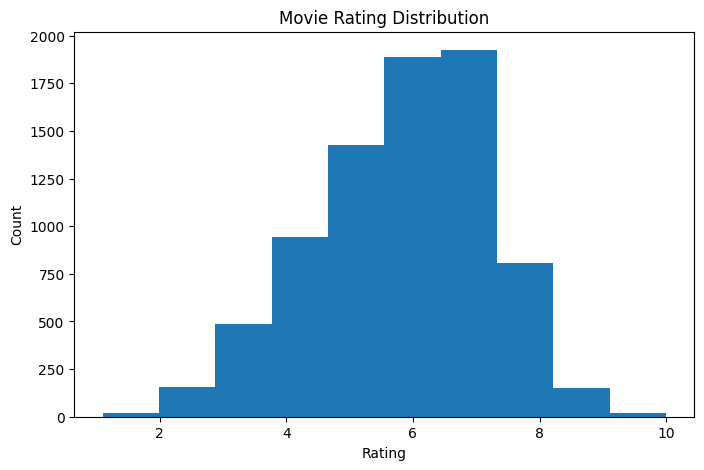

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Rating'], bins=10)
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(df['Genre'])

X = df[['Genre','Votes']]
y = df['Rating']

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

predictions = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error,r2_score

mae = mean_absolute_error(y_test,predictions)
r2 = r2_score(y_test,predictions)

print("Mean Absolute Error:",mae)
print("R2 Score:",r2)

Mean Absolute Error: 1.046397590638649
R2 Score: 0.017867692744430785


In [13]:
print("\nSample Predictions:")

results = pd.DataFrame({
    'Actual Rating': y_test.values[:10],
    'Predicted Rating': predictions[:10]
})

print(results)


Sample Predictions:
   Actual Rating  Predicted Rating
0            4.6          6.030483
1            6.8          6.931000
2            6.2          6.129033
3            6.8          4.870000
4            4.8          4.729000
5            7.1          7.037000
6            6.0          6.551917
7            7.5          8.586000
8            7.3          4.973600
9            3.5          6.034800


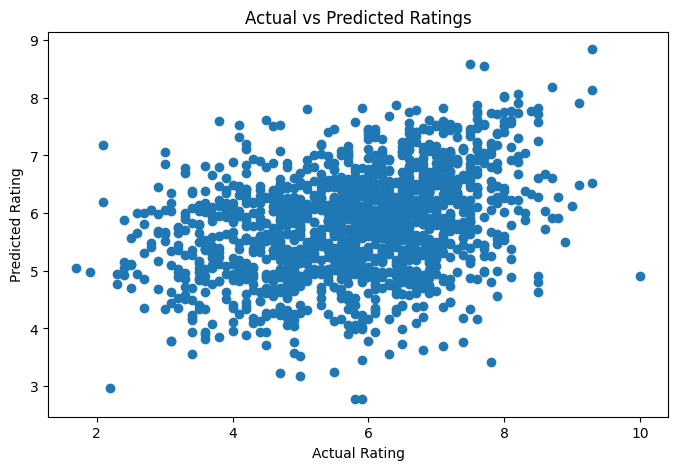

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.show()